<a href="https://colab.research.google.com/github/Saqibaminzargar/-Credit-Card-Spend-Behaviour-Analysis/blob/main/CreditCard_Spend_Behaviour_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv('/content/sample_data/credit_card_cleaned.csv')

In [2]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,SEGMENT,RISK_FLAG,STATUS
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,...,139.509787,0.000000,12,3,1,1,311,At Risk,0,Active
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,...,1072.340217,0.222222,12,3,1,1,311,At Risk,0,Inactive
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,...,627.284787,0.000000,12,3,3,3,333,Best Customer,0,Active
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,...,312.343947,0.000000,12,3,1,3,313,Big Spender at Risk,0,Active
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,...,244.791237,0.000000,12,3,1,1,311,At Risk,0,Active


In [3]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,SEGMENT,RISK_FLAG,STATUS
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,...,48.886365,0.50,6,1,3,2,132,At Risk,0,Active
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,...,312.343947,0.00,6,1,3,2,132,At Risk,0,Active
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,...,82.418369,0.25,6,1,2,2,122,At Risk,0,Active
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,...,55.755628,0.25,6,1,1,1,111,Might Churn,0,Inactive
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,...,88.288956,0.00,6,1,2,3,123,At Risk,0,Active


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,RISK_FLAG
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,...,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,...,4494.282473,1733.143852,844.906767,0.153715,11.517318,2.822235,1.937095,2.000112,303.594525,0.005251
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,...,3638.646702,2895.063757,2332.792322,0.292499,1.338331,0.527294,0.813177,0.816565,53.929480,0.072280
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,50.000000,0.000000,0.019163,0.000000,6.000000,1.000000,1.000000,1.000000,111.000000,0.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,...,1600.000000,383.276166,170.857654,0.000000,12.000000,3.000000,1.000000,1.000000,311.000000,0.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,...,3000.000000,856.901546,312.343947,0.000000,12.000000,3.000000,2.000000,2.000000,322.000000,0.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,...,6500.000000,1901.134317,788.713501,0.142857,12.000000,3.000000,3.000000,3.000000,332.000000,0.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,...,30000.000000,50721.483360,76406.207520,1.000000,12.000000,3.000000,3.000000,3.000000,333.000000,1.000000


filled missing values with median because these columns had outliers mean would have skewed

In [7]:
median_credit_limit = df['CREDIT_LIMIT'].median()
median_minimum_payments = df['MINIMUM_PAYMENTS'].median()
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(median_minimum_payments)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(median_credit_limit)

In [8]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


outliers are in purchases and balance column i kept them becoz its financial data (high balance customers)

In [9]:
Q1_purchases = df['PURCHASES'].quantile(0.25)
Q3_purchases = df['PURCHASES'].quantile(0.75)
IQR_purchases = Q3_purchases - Q1_purchases

lower_bound_purchases = Q1_purchases - 1.5 * IQR_purchases
upper_bound_purchases = Q3_purchases + 1.5 * IQR_purchases

outliers_purchases = df[(df['PURCHASES'] < lower_bound_purchases) | (df['PURCHASES'] > upper_bound_purchases)]

print(f"Number of outliers in 'PURCHASES': {len(outliers_purchases)}")

Number of outliers in 'PURCHASES': 808


In [10]:
Q1_balance = df['BALANCE'].quantile(0.25)
Q3_balance = df['BALANCE'].quantile(0.75)
IQR_balance = Q3_purchases - Q1_purchases

lower_bound_balance = Q1_balance - 1.5 * IQR_balance
upper_bound_balance = Q3_balance + 1.5 * IQR_balance

outliers_balance = df[(df['BALANCE'] < lower_bound_balance) | (df['BALANCE'] > upper_bound_balance)]

print(f"Number of outliers in 'BALANCE': {len(outliers_balance)}")

Number of outliers in 'BALANCE': 1133


In [11]:
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,SEGMENT,RISK_FLAG,STATUS
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,...,139.509787,0.000000,12,3,1,1,311,At Risk,0,Active
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,...,1072.340217,0.222222,12,3,1,1,311,At Risk,0,Inactive
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,...,627.284787,0.000000,12,3,3,3,333,Best Customer,0,Active
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,...,312.343947,0.000000,12,3,1,3,313,Big Spender at Risk,0,Active
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,...,244.791237,0.000000,12,3,1,1,311,At Risk,0,Active


In [12]:
print('TOTAL CUSTOMERS',df['CUST_ID'].count())
print('AVERAGE BALANCE',df['BALANCE'].mean().round(2))
print('AVERAGE CREDIT LIMIT',df['CREDIT_LIMIT'].mean().round(2))
print(f"RISKY CUSTOMER % {df['RISK_FLAG'].sum()/df['CUST_ID'].count()*100:.2f}%")

TOTAL CUSTOMERS 8950
AVERAGE BALANCE 1564.47
AVERAGE CREDIT LIMIT 4494.28
RISKY CUSTOMER % 0.53%


In [13]:
df['R_SCORE'] = pd.cut(df['TENURE'],3, labels=[1, 2,3])
df['F_SCORE'] = pd.qcut(df['PURCHASES_FREQUENCY'], 3, labels=[1,2,3])
df['M_SCORE'] = pd.qcut(df['PURCHASES'], 3, labels=[1,2,3])

df['RFM_SCORE'] = df['R_SCORE'].astype(str) + \
                  df['F_SCORE'].astype(str) + \
                  df['M_SCORE'].astype(str)

In [14]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,SEGMENT,RISK_FLAG,STATUS
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,...,139.509787,0.000000,12,3,1,1,311,At Risk,0,Active
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,...,1072.340217,0.222222,12,3,1,1,311,At Risk,0,Inactive
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,...,627.284787,0.000000,12,3,3,3,333,Best Customer,0,Active
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,...,312.343947,0.000000,12,3,1,3,313,Big Spender at Risk,0,Active
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,...,244.791237,0.000000,12,3,1,1,311,At Risk,0,Active


In [15]:


def label_customer(rfm):
    r = int(rfm[0])
    f = int(rfm[1])
    m = int(rfm[2])

    if r==3 and f==3 and m==3:
        return 'Best Customer'
    elif r==3 and f>=2 and m>=2:
        return 'Loyal'
    elif r>=2 and f>=2 and m>=2:
        return 'Potential Loyal'
    elif r==1 and f==1 and m==1:
        return 'Might Churn'
    elif m==3 and f==1:
        return 'Big Spender at Risk'
    else:
        return 'At Risk'

df['SEGMENT'] = df['RFM_SCORE'].apply(label_customer)

In [16]:
df['RISK_FLAG'] = 0

df.loc[
    (df['CASH_ADVANCE'] > df['CASH_ADVANCE'].quantile(0.75)) &
    (df['PAYMENTS'] < df['PAYMENTS'].quantile(0.25)) &
    (df['BALANCE'] > df['BALANCE'].quantile(0.75)),
    'RISK_FLAG'
] = 1

risky = df['RISK_FLAG'].sum()

print(f"Risky customers: {risky} ({risky/len(df)*100:.1f}%)")

Risky customers: 47 (0.5%)


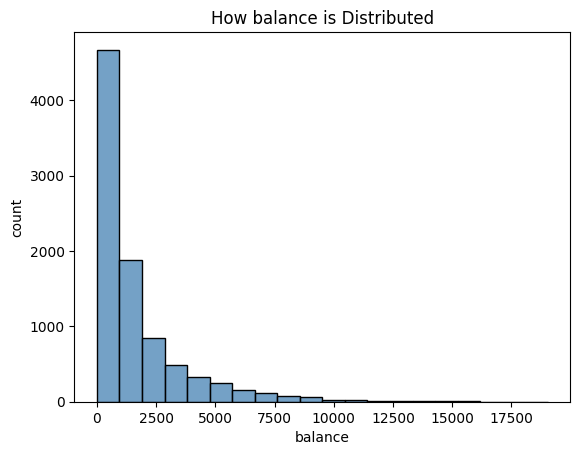

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['BALANCE'],bins=20,color='steelblue')
plt.title('How balance is Distributed')
plt.xlabel('balance')
plt.ylabel('count')
plt.show()

In [18]:
oneoff_purchase_sum=df['ONEOFF_PURCHASES'].sum()
print(f"one off purchase sum:{oneoff_purchase_sum}")
Installment_Purchases=df['ONEOFF_PURCHASES'].sum()
print(f"Installment Purchases sum:{Installment_Purchases}")
Cash_Advance=df['CASH_ADVANCE'].sum()
print(f"Cash_Advance sum:{Cash_Advance}")

one off purchase sum:5302314.470000001
Installment Purchases sum:5302314.470000001
Cash_Advance sum:8760896.456566


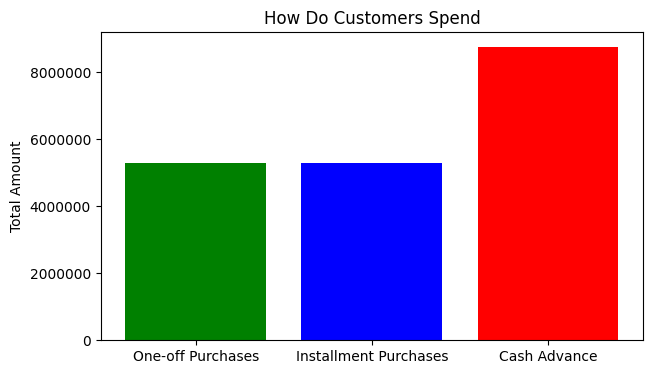

In [19]:
plt.figure(figsize=(7,4))
plt.bar(['One-off Purchases','Installment Purchases','Cash Advance'],
        [oneoff_purchase_sum,Installment_Purchases,Cash_Advance],
        color=['green','blue','red'])
plt.title('How Do Customers Spend')
plt.ylabel('Total Amount')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

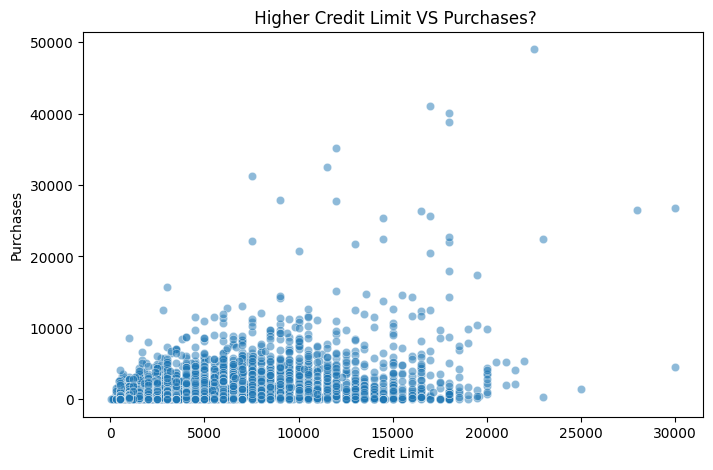

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['CREDIT_LIMIT'], y=df['PURCHASES'],alpha=.5)
plt.title(' Higher Credit Limit VS Purchases?')
plt.xlabel('Credit Limit')
plt.ylabel('Purchases')
plt.show()

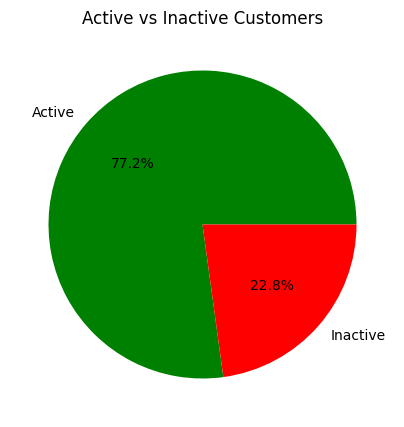

In [21]:
df['STATUS'] = df['PURCHASES'].apply(
    lambda x: 'Active' if x > 0 else 'Inactive'
)

counts = df['STATUS'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['green','red'])
plt.title('Active vs Inactive Customers')
plt.show()

SEGMENT
At Risk                3540
Loyal                  3207
Best Customer          1632
Might Churn             227
Potential Loyal         212
Big Spender at Risk     132
Name: count, dtype: int64


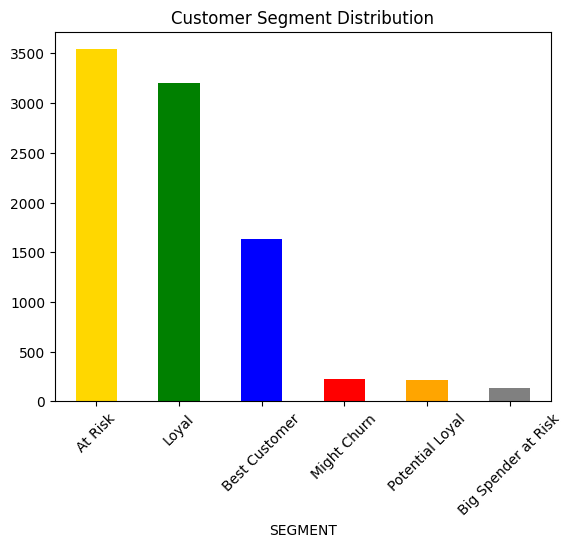

In [22]:
print(df['SEGMENT'].value_counts())

df['SEGMENT'].value_counts().plot(
    kind='bar',
    color=['gold','green','blue','red','orange','grey']
)
plt.title('Customer Segment Distribution')
plt.xticks(rotation=45)
plt.show()

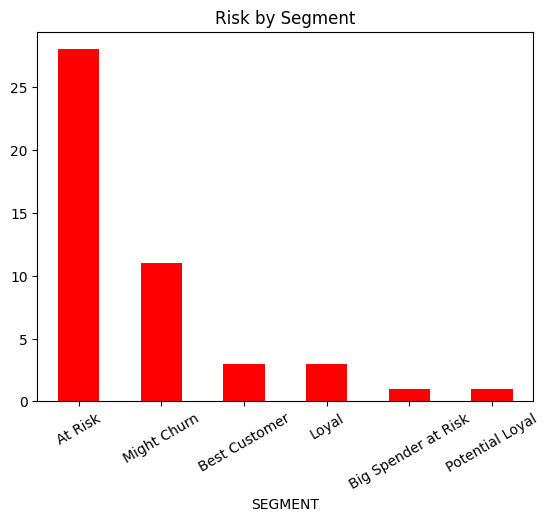

In [28]:
risk_seg = df.groupby('SEGMENT')['RISK_FLAG'].sum().sort_values(ascending=False)
risk_seg.plot(kind='bar', color='red')
plt.title('Risk by Segment')
plt.tick_params(axis='x', rotation=30)
plt.show()

<Axes: >

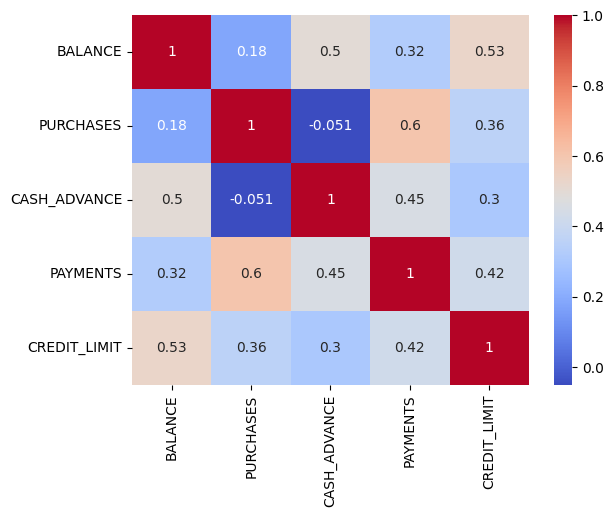

In [25]:
sns.heatmap(df[['BALANCE','PURCHASES','CASH_ADVANCE',
                'PAYMENTS','CREDIT_LIMIT']].corr(),
            annot=True, cmap='coolwarm')

In [ ]:
risk_vs_safe=df.groupby('RISK_FLAG')[['BALANCE','CASH_ADVANCE','PAYMENTS']].mean().round(2)
print(risk_vs_safe)

risk_vs_safe.T.plot(kind='bar',color=['green','red',])
plt.title('Risky vs Safe Comparison')
plt.xticks(rotation=45)
plt.show()


In [ ]:
risk_by_segement=df.groupby('SEGMENT')['RISK_FLAG'].sum().sort_values(ascending=False)
print(risk_by_segement)

risk_by_segement.plot(kind='bar',color='blue')
plt.title('Risk Flags by Customer Segment')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv('credit_card_cleaned.csv', index=False)
print("Final dataset saved ")
print(df[['RFM_SCORE','SEGMENT','RISK_FLAG']].head(10))

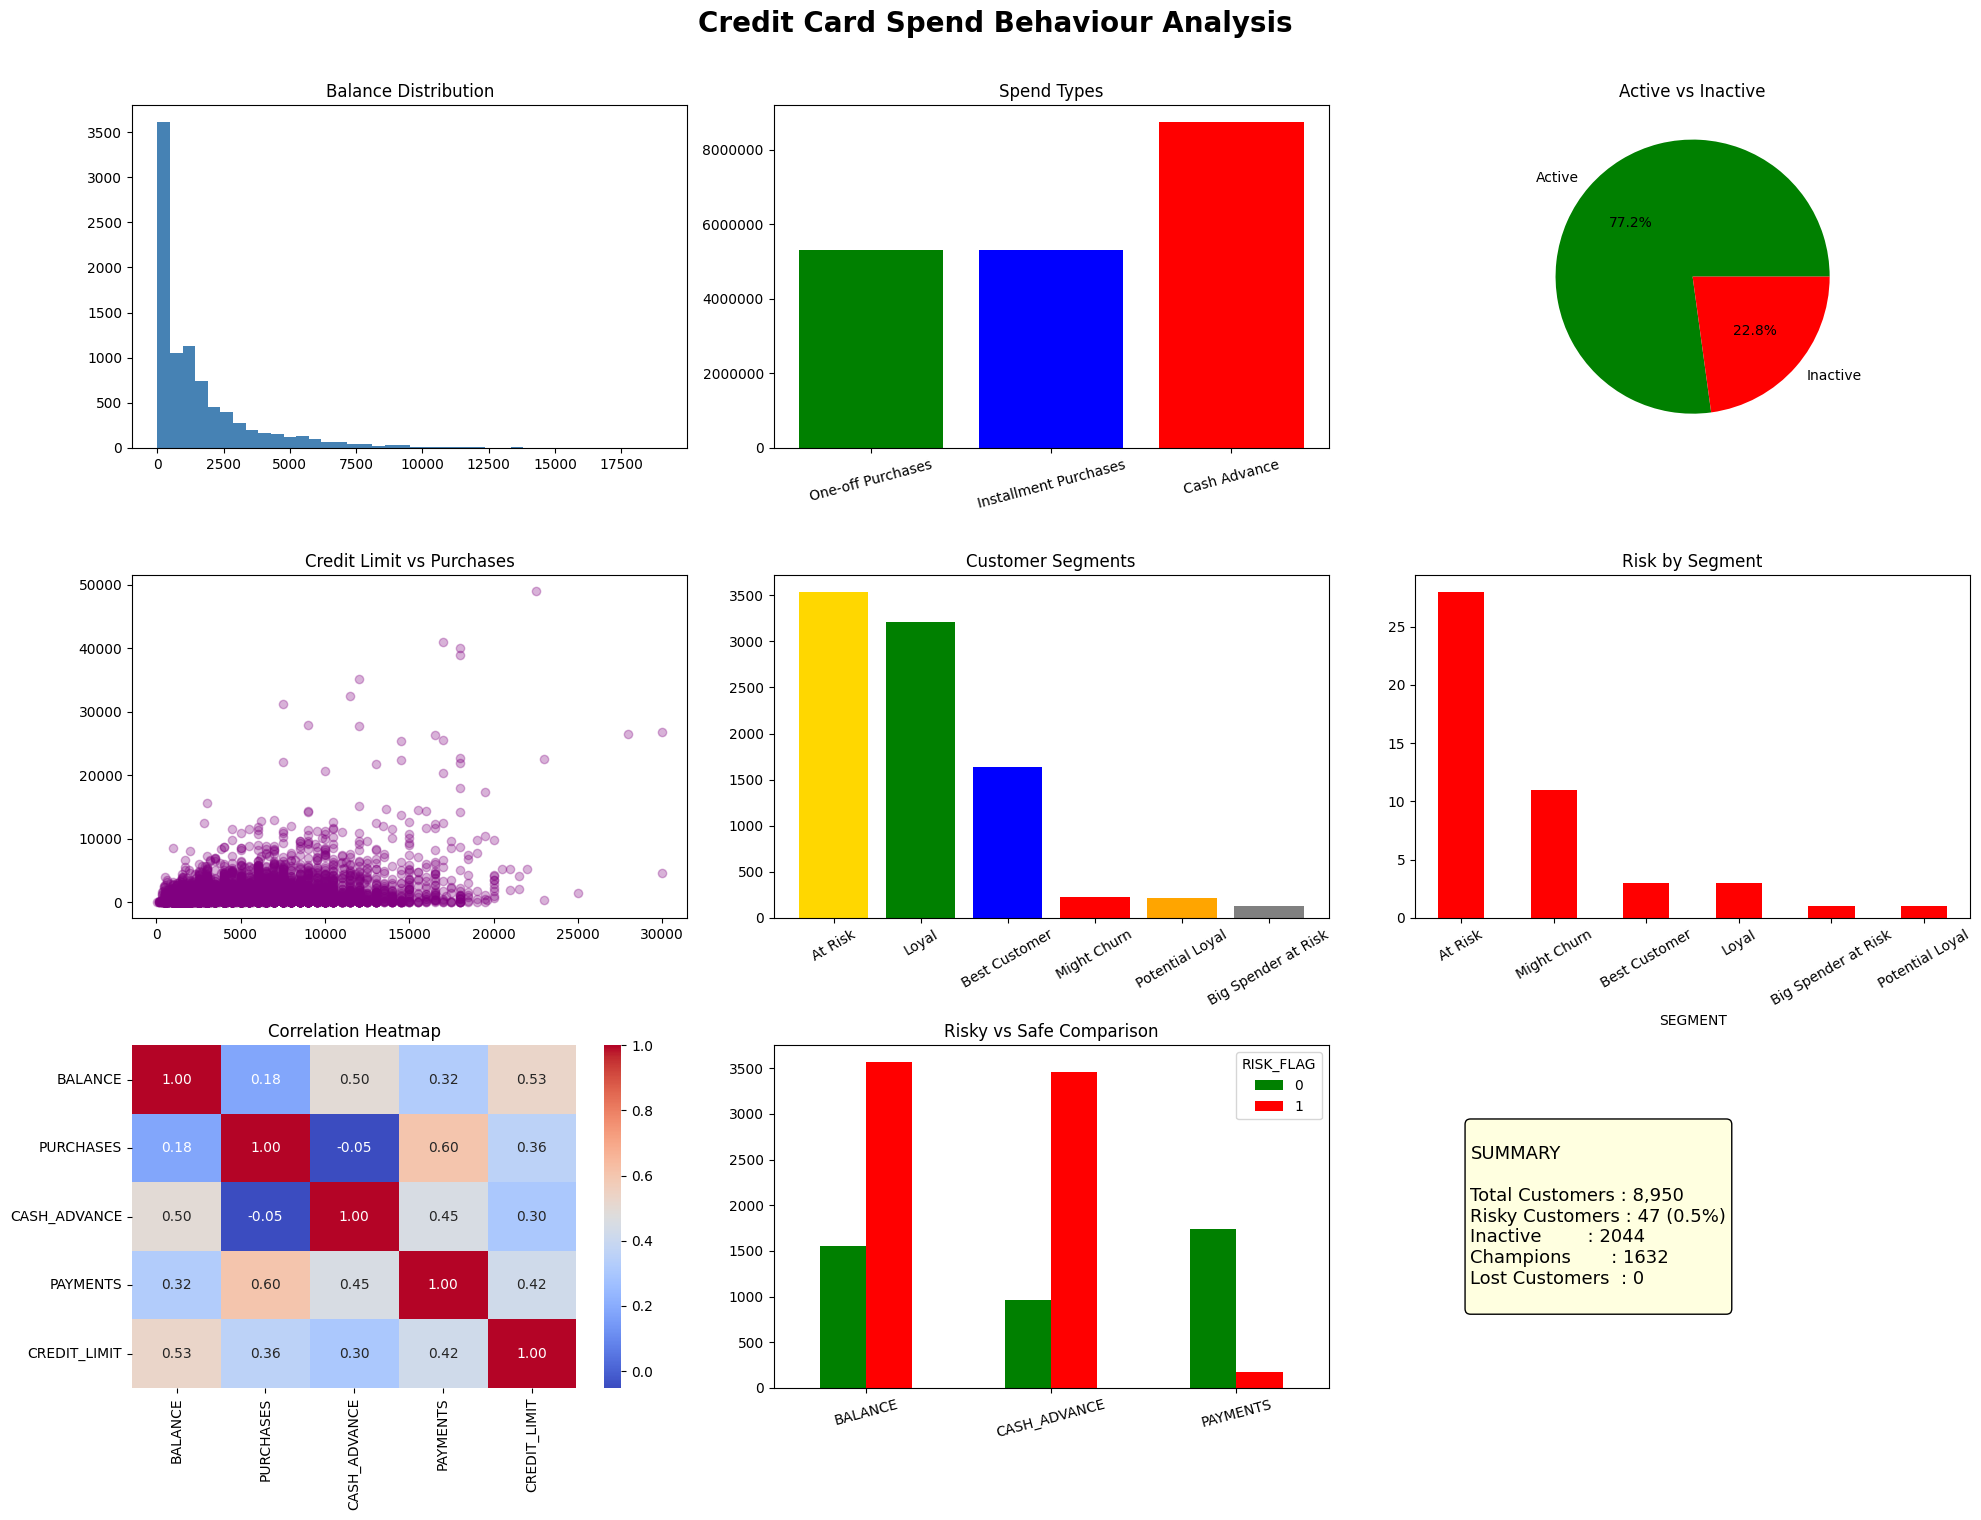

Dashboard saved


In [26]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Credit Card Spend Behaviour Analysis',
             fontsize=20, fontweight='bold', y=1.01)

# Define variables for plots
spend_data = {'One-off Purchases': oneoff_purchase_sum,
              'Installment Purchases': Installment_Purchases,
              'Cash Advance': Cash_Advance}

seg_counts = df['SEGMENT'].value_counts()
colors = ['gold','green','blue','red','orange','grey']

risk_seg = df.groupby('SEGMENT')['RISK_FLAG'].sum().sort_values(ascending=False)

# Plot 1 — Balance distribution
axes[0,0].hist(df['BALANCE'], bins=40, color='steelblue')
axes[0,0].set_title('Balance Distribution')

# Plot 2 — Spend types
axes[0,1].bar(spend_data.keys(), spend_data.values(),
              color=['green','blue','red'])
axes[0,1].set_title('Spend Types')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].ticklabel_format(axis='y',style='plain')

# Plot 3 — Active vs Inactive
axes[0,2].pie(counts, labels=counts.index,
              autopct='%1.1f%%', colors=['green','red'])
axes[0,2].set_title('Active vs Inactive')

# Plot 4 — Scatter
axes[1,0].scatter(df['CREDIT_LIMIT'], df['PURCHASES'],
                  alpha=0.3, color='purple')
axes[1,0].set_title('Credit Limit vs Purchases')

# Plot 5 — Segments
axes[1,1].bar(seg_counts.index, seg_counts.values, color=colors)
axes[1,1].set_title('Customer Segments')
axes[1,1].tick_params(axis='x', rotation=30)

# Plot 6 — Risk by segment
risk_seg.plot(ax=axes[1,2], kind='bar', color='red')
axes[1,2].set_title('Risk by Segment')
axes[1,2].tick_params(axis='x', rotation=30)

# Plot 7 — Heatmap
sns.heatmap(df[['BALANCE','PURCHASES','CASH_ADVANCE',
                'PAYMENTS','CREDIT_LIMIT']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2,0])
axes[2,0].set_title('Correlation Heatmap')

# Plot 8 — Risky vs Safe comparison
risk_compare = df.groupby('RISK_FLAG')[
    ['BALANCE','CASH_ADVANCE','PAYMENTS']
].mean()
risk_compare.T.plot(kind='bar', ax=axes[2,1],
                    color=['green','red'])
axes[2,1].set_title('Risky vs Safe Comparison')
axes[2,1].tick_params(axis='x', rotation=15)

# Plot 9 — Summary text box
axes[2,2].axis('off')
summary = f"""
SUMMARY

Total Customers : {len(df):,}
Risky Customers : {risky} ({risky/len(df)*100:.1f}%)
Inactive        : {counts['Inactive']}
Champions       : {(df['SEGMENT']=='Best Customer').sum()}
Lost Customers  : {(df['SEGMENT']=='Lost').sum()}
"""
axes[2,2].text(0.1, 0.5, summary,
               fontsize=13, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved")